# Laboratorio 6. Regresión logística

En este notebook construiremos un modelo de **regresión logística** para un problema de clasificación binaria utilizando un dataset incluido en `scikit-learn`.

Trabajaremos con el dataset **Breast Cancer Wisconsin**, cuyo objetivo es clasificar tumores como benignos o malignos a partir de características obtenidas de imágenes de masas celulares.

## Carga de datos

Primero cargamos el dataset utilizando `load_breast_cancer`.

El objeto contiene tanto los predictores como la variable respuesta y los nombres de las variables.


In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

data = load_breast_cancer()

In [6]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

Construimos la matriz de predictores `X` y el vector de respuesta `y`.

In [7]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

Construimos la matriz de predictores `X` y el vector de respuesta `y`.

In [8]:
X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

## Exploración de datos

Antes de ajustar el modelo, revisamos la estructura de los predictores y la respuesta

In [9]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [10]:
X.shape

(569, 30)

In [11]:
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

## Separación de conjuntos de entrenamiento y prueba

Dividiremos los datos en un conjunto de entrenamiento y un conjunto de prueba.

Utilizamos `stratify=y` para conservar aproximadamente la misma proporción de clases en ambos conjuntos.


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((426, 30), (143, 30))

## Ajustar la regresión logística

Ahora ajustamos el modelo utilizando los datos de entrenamiento.

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=10000
)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

El modelo estima un intercepto $\beta_0$ y un coeficiente $\beta_i$ para cada predictor.

Podemos observar los coeficientes:

In [16]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Beta": model.coef_[0]
})

coeficientes

,Variable,Beta
0,mean radius,0.757452
1,mean texture,0.138489
2,mean perimeter,-0.286560
3,mean area,0.026807
4,mean smoothness,-0.161432
5,mean compactness,-0.203581
6,mean concavity,-0.429755
7,mean concave points,-0.232278
8,mean symmetry,-0.265495
9,mean fractal dimension,-0.037114


## Interpretar los coeficientes

En regresión logística:

$$
\log\left(\frac{p}{1-p}\right)
=
\beta_0+\beta_1x_1+\cdots+\beta_px_p
$$

Un incremento de una unidad en $x_i$, manteniendo los demás predictores constantes, cambia los **log-odds** en $\beta_i$.

Al aplicar la función exponencial:

$$
e^{\beta_i}
$$

obtenemos el factor por el cual se multiplican los **odds**.

In [17]:
coeficientes["Odds Ratio"] = np.exp(
    coeficientes["Beta"]
)

coeficientes

,Variable,Beta,Odds Ratio
0,mean radius,0.757452,2.132835
1,mean texture,0.138489,1.148537
2,mean perimeter,-0.286560,0.750842
3,mean area,0.026807,1.027169
4,mean smoothness,-0.161432,0.850925
5,mean compactness,-0.203581,0.815804
6,mean concavity,-0.429755,0.650669
7,mean concave points,-0.232278,0.792726
8,mean symmetry,-0.265495,0.766826
9,mean fractal dimension,-0.037114,0.963566


## Probabilidades estimadas

La regresión logística no produce directamente una clase. El modelo estima la probabilidad de que cada observación pertenezca a la **clase positiva**.

En nuestro caso:

$$
P(Y=1\mid X)
=
P(\text{benign}\mid X)
$$

Podemos obtener estas probabilidades utilizando `predict_proba()`:


In [18]:
probabilidades = model.predict_proba(X_test)

probabilidades[:5]

array([[0.01851079, 0.98148921],
       [0.99816902, 0.00183098],
       [0.17664237, 0.82335763],
       [0.23384359, 0.76615641],
       [0.19969055, 0.80030945]])

El resultado contiene una columna para cada clase:

$$
P(Y=0\mid X)
\qquad
P(Y=1\mid X)
$$

Podemos verificar el orden de las clases utilizado por el modelo:

In [19]:
model.classes_

array([0, 1])

Como la clase `1` corresponde a **benign**, la segunda columna contiene:
$$
P(Y=1\mid X)
=
P(\text{benign}\mid X)
$$

In [20]:
p_benign = probabilidades[:, 1]

p_benign[:10]

array([9.81489205e-01, 1.83098082e-03, 8.23357632e-01, 7.66156406e-01,
       8.00309452e-01, 1.12607434e-06, 6.74834952e-02, 9.73597120e-05,
       1.79109716e-01, 9.99265685e-01])

## Del modelo a la clasificación

Para convertir las probabilidades estimadas en clases debemos establecer un **umbral de decisión** $c$.

Utilizando la clase `1` como referencia:

$$
\hat{Y} =
\begin{cases}
1, & \hat{p} \geq c,\\
0, & \hat{p} < c.
\end{cases}
$$

Comenzaremos con:

$$
c=0.5
$$

In [21]:
c = 0.5

y_pred = (p_benign >= c).astype(int)

y_pred[:10]

array([1, 0, 1, 1, 1, 0, 0, 0, 0, 1])

Por lo tanto:

- si $\hat p \geq 0.5$, clasificamos la observación como **benigna**;
- si $\hat p < 0.5$, la clasificamos como **maligna**.

Podemos comparar las probabilidades, predicciones y clases reales:

In [22]:
resultados = pd.DataFrame({
    "Probabilidad": p_benign,
    "Predicción": y_pred,
    "Real": y_test.values
})

resultados.head(10)

,Probabilidad,Predicción,Real
0,0.981489,1,1
1,0.001831,0,0
2,0.823358,1,1
3,0.766156,1,1
4,0.800309,1,0
5,0.000001,0,0
6,0.067483,0,0
7,0.000097,0,0
8,0.179110,0,0
9,0.999266,1,1


## Matriz de confusión

Ahora comparamos las clases predichas con las clases reales.

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[48,  5],
       [ 1, 89]])

`scikit-learn` utiliza por defecto la clase `1` como positiva, por lo que la matriz se organiza como:

```text
[[TN, FP],
 [FN, TP]]
```

Podemos extraer sus componentes:

In [24]:
TN, FP, FN, TP = cm.ravel()

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

TN: 48
FP: 5
FN: 1
TP: 89


## Métricas de clasificación

A partir de la matriz de confusión podemos calcular diferentes métricas.

### Accuracy

El **accuracy** representa la proporción total de observaciones clasificadas correctamente:

$$
\text{Accuracy}
=
\frac{TP+TN}{TP+TN+FP+FN}
$$

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

accuracy

0.958041958041958

### Precision

La **precision** responde:

> De todos los tumores clasificados como benignos, ¿qué proporción realmente era benigna?

$$
\text{Precision}
=
\frac{TP}{TP+FP}
$$

In [26]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

precision

0.9468085106382979

### Recall

El **recall** responde:

> De todos los tumores realmente benignos, ¿qué proporción fue identificada correctamente como benigna?

$$
\text{Recall}
=
\frac{TP}{TP+FN}
$$

In [27]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

recall

0.9888888888888889

In [28]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.958041958041958
Precision: 0.9468085106382979
Recall: 0.9888888888888889


## Curva ROC

Hasta ahora evaluamos el clasificador utilizando un único umbral:

$$
c = 0.5
$$

Sin embargo, diferentes valores de $c$ producen diferentes cantidades de verdaderos positivos y falsos positivos.

La **curva ROC** permite estudiar el comportamiento del clasificador para distintos valores del umbral.

Para cada umbral calculamos:

$$
\operatorname{TPR}
=
\frac{TP}{TP+FN}
$$

y

$$
\operatorname{FPR}
=
\frac{FP}{FP+TN}
$$

donde:

- `TPR` corresponde al **recall** de la clase positiva;
- `FPR` representa la proporción de observaciones negativas clasificadas incorrectamente como positivas.

En este dataset, la clase positiva es:

$$
1 = \text{benign}
$$

Podemos calcular estos valores utilizando `roc_curve()`:

In [29]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    p_benign
)

In [30]:
roc = pd.DataFrame({
    "Threshold": thresholds,
    "FPR": fpr,
    "TPR": tpr
})

roc.head(10)

,Threshold,FPR,TPR
0,inf,0.000000,0.000000
1,0.999994,0.000000,0.011111
2,0.823358,0.000000,0.944444
3,0.800309,0.018868,0.944444
4,0.766156,0.018868,0.955556
5,0.704369,0.075472,0.955556
6,0.609635,0.075472,0.977778
7,0.568727,0.094340,0.977778
8,0.513797,0.094340,0.988889
9,0.318261,0.132075,0.988889


Cada fila representa un umbral diferente y genera un punto:

$$
(\operatorname{FPR},\operatorname{TPR})
$$

La curva ROC se obtiene al representar todos estos puntos.

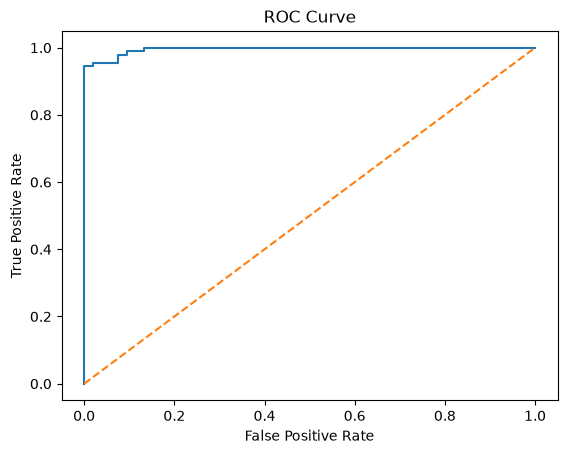

In [31]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

## Área bajo la curva

La curva ROC puede resumirse utilizando el **Area Under the Curve (AUC)**.

In [32]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    p_benign
)

auc

0.9955974842767296

El AUC toma valores entre `0` y `1`.

En general:

- un valor cercano a `1` indica una alta capacidad de discriminación;
- un valor cercano a `0.5` indica un desempeño similar al de una clasificación aleatoria.

El AUC evalúa la capacidad del modelo para separar las clases considerando distintos valores del umbral.